In [5]:
import pandas as pd

df = pd.read_csv("Womens_Clothing_E-Commerce_Reviews.csv")
df.columns
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [6]:
import pandas as pd
import re

# Define clean_text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Define map_sentiment function
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

# Reload the DataFrame to ensure all original columns are present
df = pd.read_csv("Womens_Clothing_E-Commerce_Reviews.csv")

# Drop rows where 'Review Text' or 'Rating' are missing
df = df.dropna(subset=["Review Text", "Rating"])

# Sample the DataFrame (if it has more than 8000 rows, for consistency with previous steps)
df = df.sample(min(len(df), 8000), random_state=42)

# Apply text cleaning and sentiment mapping
df["cleaned"] = df["Review Text"].apply(clean_text)
df["sentiment"] = df["Rating"].apply(map_sentiment)

# Display first few rows and columns to verify
print("DataFrame columns after preparation:")
print(df.columns)
df.head()

DataFrame columns after preparation:
Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'cleaned', 'sentiment'],
      dtype='object')


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,cleaned,sentiment
13365,13365,948,24,Stunning!,This sweater is so beautiful on. it is thick m...,5,1,4,General,Tops,Sweaters,this sweater is so beautiful on it is thick ma...,positive
19834,19834,875,63,NaN,This piece is almost what i want... i tried on...,4,1,38,General,Tops,Knits,this piece is almost what i want i tried on th...,positive
18722,18722,829,42,Nice blouse,Really like this blouse but am returning for a...,4,1,0,General,Tops,Blouses,really like this blouse but am returning for a...,positive
10635,10635,1068,39,Perfect summer pants,These are the perfect light weight relaxing su...,5,1,0,General Petite,Bottoms,Pants,these are the perfect light weight relaxing su...,positive
7348,7348,1030,44,Terrible cut,These look nothing like the picture! they are ...,2,1,4,General,Bottoms,Jeans,these look nothing like the picture they are s...,negative


### Sentiment Distribution by Department Name

Let's visualize how sentiment is distributed across different 'Department Name' categories to see if certain departments tend to receive more positive, neutral, or negative feedback.

### Sentiment Distribution by Department Name

Let's visualize how sentiment is distributed across different 'Department Name' categories to see if certain departments tend to receive more positive, neutral, or negative feedback.

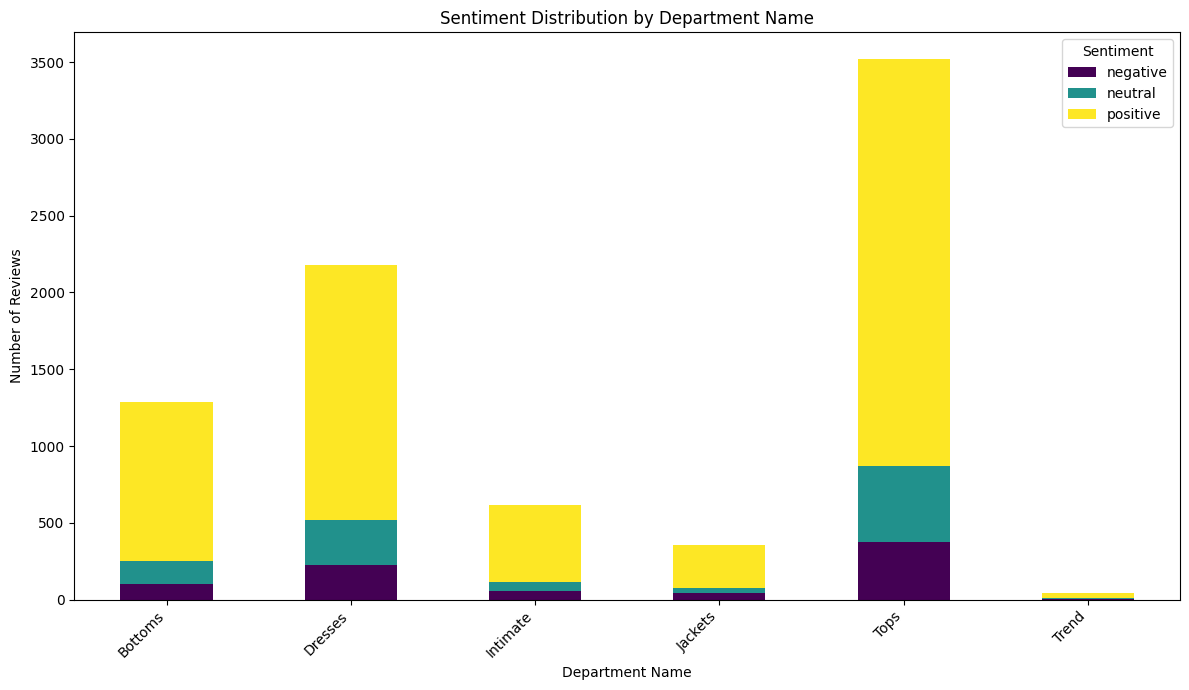

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# Define clean_text function (ensuring it's available for df preprocessing)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Define map_sentiment function (ensuring it's available for df preprocessing)
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

# Ensure df is properly prepared with 'sentiment' column
# This block is added to make the cell self-sufficient in case df state is lost
if 'sentiment' not in df.columns or 'cleaned' not in df.columns:
    print("Re-running df preprocessing to ensure 'sentiment' column exists.")
    # Reload the DataFrame to ensure all original columns are present
    df = pd.read_csv("Womens_Clothing_E-Commerce_Reviews.csv")

    # Drop rows where 'Review Text' or 'Rating' are missing
    df = df.dropna(subset=["Review Text", "Rating"])

    # Sample the DataFrame (if it has more than 8000 rows)
    df = df.sample(min(len(df), 8000), random_state=42)

    # Apply text cleaning and sentiment mapping
    df["cleaned"] = df["Review Text"].apply(clean_text)
    df["sentiment"] = df["Rating"].apply(map_sentiment)

sentiment_dept_counts = df.groupby(['Department Name', 'sentiment']).size().unstack(fill_value=0)
sentiment_dept_counts = sentiment_dept_counts.reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
sentiment_dept_counts.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')

plt.title('Sentiment Distribution by Department Name')
plt.xlabel('Department Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [8]:
df = df.sample(min(len(df), 8000), random_state=42)

In [9]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned"] = df["Review Text"].apply(clean_text)

In [28]:
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Rating"].apply(map_sentiment)
df["sentiment"].value_counts()

,count
sentiment,
positive,6154
neutral,1037
negative,809


In [29]:
display(sentiment_dept_counts)

sentiment,negative,neutral,positive
Department Name,,,
Bottoms,103,151,1033
Dresses,227,294,1658
Intimate,53,59,501
Jackets,42,35,281
Tops,377,493,2648
Trend,7,5,29


In [31]:
from sklearn.model_selection import train_test_split

X = df["cleaned"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.770625
              precision    recall  f1-score   support

    negative       0.42      0.56      0.48       158
     neutral       0.33      0.46      0.39       205
    positive       0.95      0.85      0.90      1237

    accuracy                           0.77      1600
   macro avg       0.57      0.62      0.59      1600
weighted avg       0.82      0.77      0.79      1600



In [15]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

predict_sentiment("Terrible quality and I want to return this item")

'negative'

### Using a Hugging Face Model for Sentiment Analysis

To try out a Hugging Face model, we can leverage the `transformers` library. Below is an example using a pre-trained sentiment analysis pipeline.

In [16]:
from transformers import pipeline

# Load a pre-trained sentiment analysis model from Hugging Face
sentiment_pipeline = pipeline("sentiment-analysis")

# Test with an example text
text_to_analyze = "I love this product, it's absolutely fantastic!"
hf_result_positive = sentiment_pipeline(text_to_analyze)
print(f"Text: '{text_to_analyze}'\nHugging Face Sentiment: {hf_result_positive}")

text_to_analyze_negative = "This product is terrible, I'm very disappointed."
hf_result_negative = sentiment_pipeline(text_to_analyze_negative)
print(f"\nText: '{text_to_analyze_negative}'\nHugging Face Sentiment: {hf_result_negative}")

text_to_analyze_neutral = "The product arrived on time and was as described."
hf_result_neutral = sentiment_pipeline(text_to_analyze_neutral)
print(f"\nText: '{text_to_analyze_neutral}'\nHugging Face Sentiment: {hf_result_neutral}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: 'I love this product, it's absolutely fantastic!'
Hugging Face Sentiment: [{'label': 'POSITIVE', 'score': 0.999881386756897}]

Text: 'This product is terrible, I'm very disappointed.'
Hugging Face Sentiment: [{'label': 'NEGATIVE', 'score': 0.9997921586036682}]

Text: 'The product arrived on time and was as described.'
Hugging Face Sentiment: [{'label': 'POSITIVE', 'score': 0.8679978251457214}]


### Comparison Table: Custom Model vs. Hugging Face Model

Now, let's create a table comparing the predictions of our trained model and the Hugging Face model on a few sample texts.

In [17]:
import pandas as pd

sample_texts = [
    "This product is amazing, I highly recommend it!",
    "It's okay, nothing special but not bad either.",
    "Absolutely terrible, a complete waste of money.",
    "The quality is good, but the sizing is a bit off.",
    "I am so disappointed with this purchase, it broke after one use."
]

# Predictions from our current model
current_model_predictions = [predict_sentiment(text) for text in sample_texts]

# Predictions from the Hugging Face model
huggingface_predictions = [sentiment_pipeline(text)[0]['label'] for text in sample_texts]

# Combine the results into a DataFrame
comparison_df = pd.DataFrame({
    'Text': sample_texts,
    'Current Model Prediction': current_model_predictions,
    'Hugging Face Prediction': huggingface_predictions
})

display(comparison_df)

,Text,Current Model Prediction,Hugging Face Prediction
0,"This product is amazing, I highly recommend it!",positive,POSITIVE
1,"It's okay, nothing special but not bad either.",negative,POSITIVE
2,"Absolutely terrible, a complete waste of money.",negative,NEGATIVE
3,"The quality is good, but the sizing is a bit off.",neutral,NEGATIVE
4,"I am so disappointed with this purchase, it br...",negative,NEGATIVE


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

negative_reviews = df[df["sentiment"] == "negative"]["cleaned"]

topic_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=40
)

topic_matrix = topic_vectorizer.fit_transform(negative_reviews)

topic_words = topic_vectorizer.get_feature_names_out()
topic_freq = topic_matrix.toarray().sum(axis=0)

topic_df = pd.DataFrame({
    "topic": topic_words,
    "count": topic_freq
}).sort_values("count", ascending=False)

topic_df.head(10)

,topic,count
15,like,376
6,dress,356
7,fabric,228
8,fit,222
31,size,210
13,just,206
16,look,188
32,small,177
24,ordered,169
12,im,159


### Sentiment Distribution Visualization

Let's visualize the overall distribution of sentiments (negative, neutral, positive) in our dataset to understand the class balance.

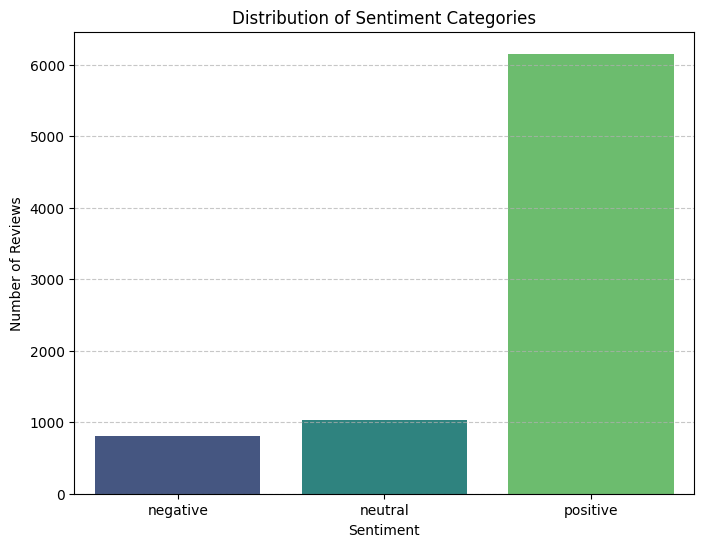

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each sentiment category
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']

# Define a custom order for sentiments
sentiment_order = ['negative', 'neutral', 'positive']
sentiment_counts['sentiment'] = pd.Categorical(sentiment_counts['sentiment'], categories=sentiment_order, ordered=True)
sentiment_counts = sentiment_counts.sort_values('sentiment')

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='sentiment', y='count', data=sentiment_counts, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
!pip install wordcloud

### Word Cloud of Most Frequent Words in Negative Reviews

Let's visualize the most frequent words found in negative reviews using a word cloud to quickly identify common themes.

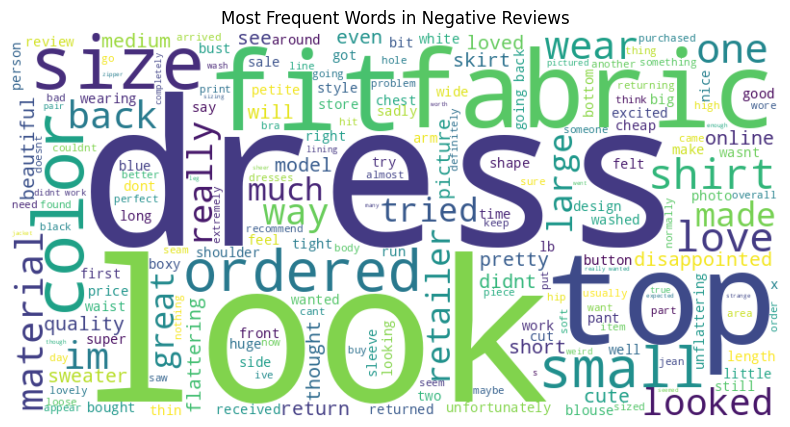

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all cleaned negative reviews into a single string
# Alternatively, if topic_df contains the exact words needed, we can use that.
# For a proper word cloud, it's better to use the raw text or a frequency dictionary.
# Let's use the negative_reviews series.
all_negative_words = ' '.join(negative_reviews)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_negative_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews')
plt.show()

In [22]:
def extract_topic(text):
    cleaned = clean_text(text)
    vec = topic_vectorizer.transform([cleaned])
    counts = vec.toarray()[0]

    if counts.sum() == 0:
        return "general"

    return topic_words[counts.argmax()]

extract_topic("Terrible quality and I want to return this item")

'quality'

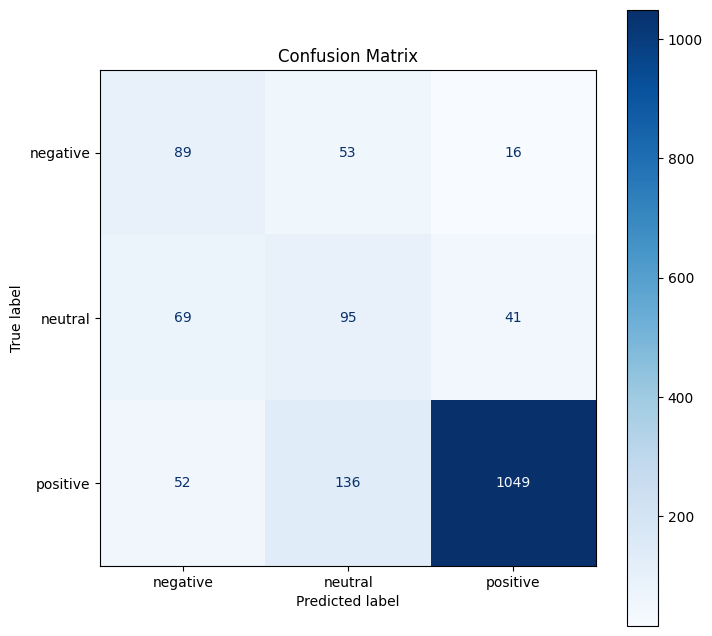

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define the order of sentiment classes (for consistency in the confusion matrix)
labels = ['negative', 'neutral', 'positive']

# Draw the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=labels, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

In [24]:
# To run this Streamlit app in Colab, you need to install Streamlit first.
# This line should ideally be run once, or handled in a requirements.txt for actual deployment.
!pip install streamlit

import streamlit as st
import requests

st.title("🤖 Hugging Face ML Sentiment Analyzer")

user_input = st.text_area("Enter text for sentiment analysis:")

if st.button("Analyze Sentiment"):
    if user_input:
        # Using a specific Hugging Face sentiment analysis model's inference API.
        # Example: distilbert-base-uncased-finetuned-sst-2-english
        API_URL = "https://api-inference.huggingface.co/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english"

        # IMPORTANT: Replace "YOUR_HF_TOKEN" with your actual Hugging Face API token.
        # You can get one from your Hugging Face settings (https://huggingface.co/settings/tokens).
        # For secure deployment, consider using Streamlit secrets (st.secrets["HF_TOKEN"]).
        headers = {"Authorization": "Bearer YOUR_HF_TOKEN"}

        try:
            response = requests.post(API_URL, headers=headers, json={"inputs": user_input})
            response.raise_for_status() # Raise an exception for HTTP errors (e.g., 401, 404, 500)
            result = response.json()

            st.subheader("Analysis Result:")
            # Hugging Face API response for sentiment analysis is typically a list of dictionaries
            # e.g., [{'label': 'POSITIVE', 'score': 0.999...}]
            if isinstance(result, list) and result:
                sentiment_label = result[0].get('label')
                sentiment_score = result[0].get('score')
                st.write(f"**Sentiment:** {sentiment_label}")
                st.write(f"**Confidence:** {sentiment_score:.2f}")
            else:
                st.write("Could not parse sentiment from API response.")
                st.write(result) # Display raw result for debugging
        except requests.exceptions.RequestException as e:
            st.error(f"Error connecting to Hugging Face API: {e}")
            st.info("Please ensure your Hugging Face token is correct and the model URL is valid.")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 36.7 MB/s eta 0:00:00


2026-05-06 11:24:03.209 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.426 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-06 11:24:03.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 11:24:03.433 Thread 'MainThread': mi

In [25]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
matplotlib
seaborn
transformers
wordcloud
requests

Writing requirements.txt
